# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np

np.random.seed(42)

expressao_up = np.random.normal(loc=2, scale=0.5, size=500)

expressao_down = np.random.normal(loc=-2, scale=0.5, size=500)

expressao = np.concatenate([expressao_up, expressao_down])

expressao

array([ 2.24835708,  1.93086785,  2.32384427,  2.76151493,  1.88292331,
        1.88293152,  2.78960641,  2.38371736,  1.76526281,  2.27128002,
        1.76829115,  1.76713512,  2.12098114,  1.04335988,  1.13754108,
        1.71885624,  1.49358444,  2.15712367,  1.54598796,  1.29384815,
        2.73282438,  1.88711185,  2.0337641 ,  1.28762591,  1.72780864,
        2.05546129,  1.42450321,  2.18784901,  1.69968066,  1.85415313,
        1.69914669,  2.92613909,  1.99325139,  1.47114454,  2.41127246,
        1.38957818,  2.1044318 ,  1.02016494,  1.33590698,  2.09843062,
        2.36923329,  2.08568414,  1.94217586,  1.84944815,  1.260739  ,
        1.6400779 ,  1.76968061,  2.52856111,  2.17180914,  1.11847992,
        2.16204198,  1.80745886,  1.661539  ,  2.30583814,  2.51549976,
        2.46564006,  1.58039124,  1.84539381,  2.16563172,  2.48777256,
        1.76041288,  1.90717051,  1.44683251,  1.40189669,  2.40626291,
        2.67812001,  1.96399494,  2.50176645,  2.18081801,  1.67

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [2]:
import pandas as pd

np.random.seed(42)

num_genes_up = np.random.randint(100, 500, size=500)

num_genes_down = np.random.randint(100, 500, size=500)

num_genes = np.concatenate([num_genes_up, num_genes_down])

df = pd.DataFrame({
    "expressao": expressao,
    "num_genes": num_genes
})

df

,expressao,num_genes
0,2.248357,202
1,1.930868,448
2,2.323844,370
3,2.761515,206
4,1.882923,171
...,...,...
995,-2.140550,326
996,-1.101157,470
997,-1.679579,114
998,-2.285589,291


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Vou categorizar usando critérios baseados em quantis da expressão gênica. 
- Grupo 1: Expressão muito baixa (downregulated)
- Grupo 2: Expressão baixa
- Grupo 3: Expressão levemente abaixo da média
- Grupo 4: Expressão levemente acima da média
- Grupo 5: Expressão alta
- Grupo 6: Expressão muito alta (upregulated)

Critérios baseados nos percentis da distribuição.

In [3]:
q1 = df["expressao"].quantile(0.166)
q2 = df["expressao"].quantile(0.332)
q3 = df["expressao"].quantile(0.5)
q4 = df["expressao"].quantile(0.666)
q5 = df["expressao"].quantile(0.832)

def categoriza(x):
    if x <= q1:
        return "Grupo 1"
    elif x <= q2:
        return "Grupo 2"
    elif x <= q3:
        return "Grupo 3"
    elif x <= q4:
        return "Grupo 4"
    elif x <= q5:
        return "Grupo 5"
    else:
        return "Grupo 6"

df["grupo"] = df["expressao"].apply(categoriza)

df

,expressao,num_genes,grupo
0,2.248357,202,Grupo 6
1,1.930868,448,Grupo 5
2,2.323844,370,Grupo 6
3,2.761515,206,Grupo 6
4,1.882923,171,Grupo 5
...,...,...,...
995,-2.140550,326,Grupo 2
996,-1.101157,470,Grupo 3
997,-1.679579,114,Grupo 3
998,-2.285589,291,Grupo 1


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [4]:
def tabela_frequencia(series):
    freq = series.value_counts()
    resultado = pd.DataFrame({
        "valor": freq.index,
        "frequencia": freq.values
    })
    return resultado

tabela_expressao = tabela_frequencia(df["expressao"])
tabela_expressao.head(10)

,valor,frequencia
0,-1.713709,1
1,2.248357,1
2,1.930868,1
3,2.323844,1
4,2.761515,1
5,1.882923,1
6,1.882932,1
7,2.789606,1
8,-2.023856,1
9,-2.483488,1


In [5]:
tabela_num_genes = tabela_frequencia(df["num_genes"])
tabela_num_genes.head(10)

,valor,frequencia
0,198,9
1,445,7
2,152,7
3,351,7
4,291,7
5,259,7
6,153,7
7,243,7
8,332,7
9,269,6


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

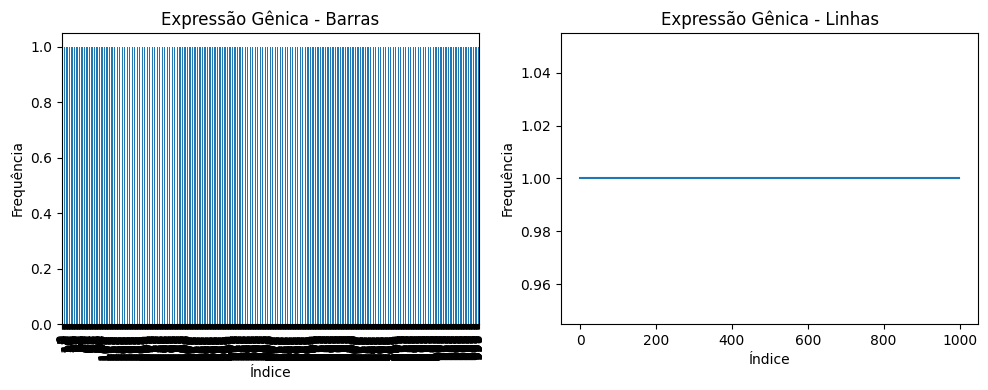

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
tabela_expressao["frequencia"].plot(kind="bar")
plt.title("Expressão Gênica - Barras")
plt.xlabel("Índice")
plt.ylabel("Frequência")

plt.subplot(1, 2, 2)
tabela_expressao["frequencia"].plot(kind="line")
plt.title("Expressão Gênica - Linhas")
plt.xlabel("Índice")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

### Expressão

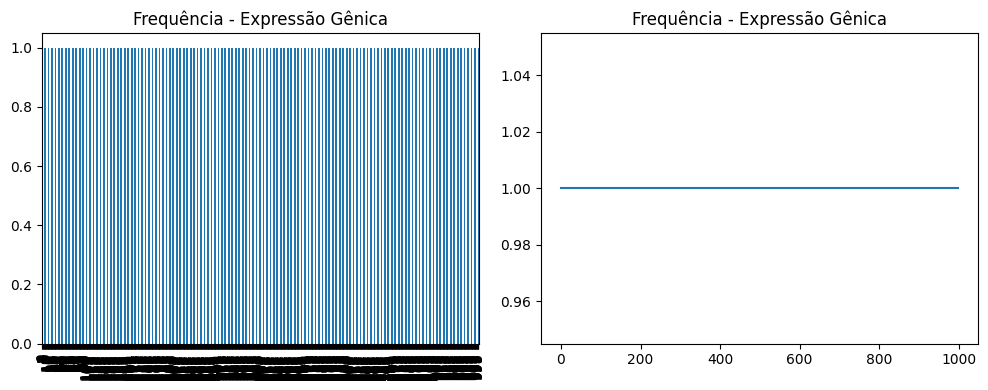

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
tabela_expressao["frequencia"].plot(kind="bar")
plt.title("Frequência - Expressão Gênica")

plt.subplot(1, 2, 2)
tabela_expressao["frequencia"].plot(kind="line")
plt.title("Frequência - Expressão Gênica")

plt.tight_layout()
plt.show()

### Número

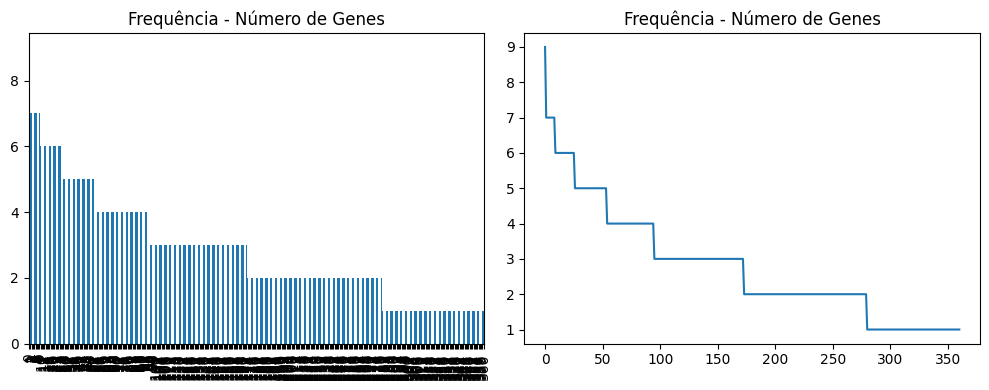

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
tabela_num_genes["frequencia"].plot(kind="bar")
plt.title("Frequência - Número de Genes")

plt.subplot(1, 2, 2)
tabela_num_genes["frequencia"].plot(kind="line")
plt.title("Frequência - Número de Genes")

plt.tight_layout()
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

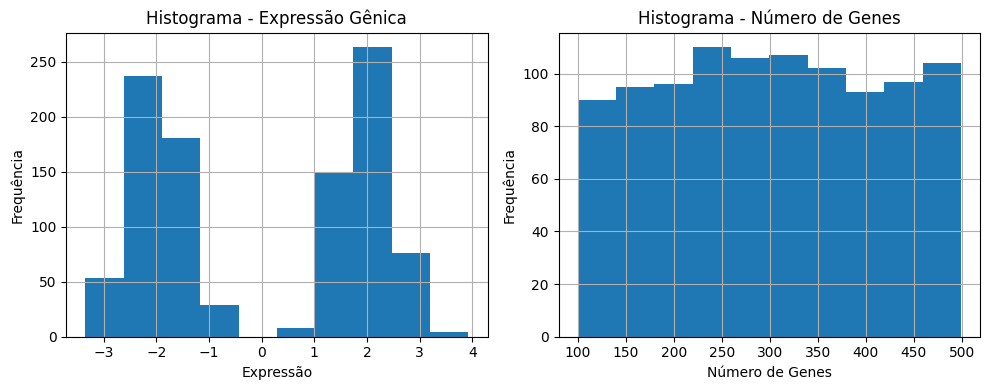

In [9]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df["expressao"].hist()
plt.title("Histograma - Expressão Gênica")
plt.xlabel("Expressão")
plt.ylabel("Frequência")

plt.subplot(1, 2, 2)
df["num_genes"].hist()
plt.title("Histograma - Número de Genes")
plt.xlabel("Número de Genes")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

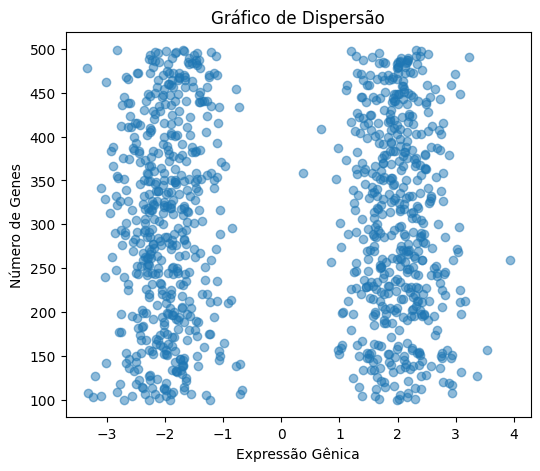

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(df["expressao"], df["num_genes"], alpha=0.5)
plt.title("Gráfico de Dispersão")
plt.xlabel("Expressão Gênica")
plt.ylabel("Número de Genes")
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

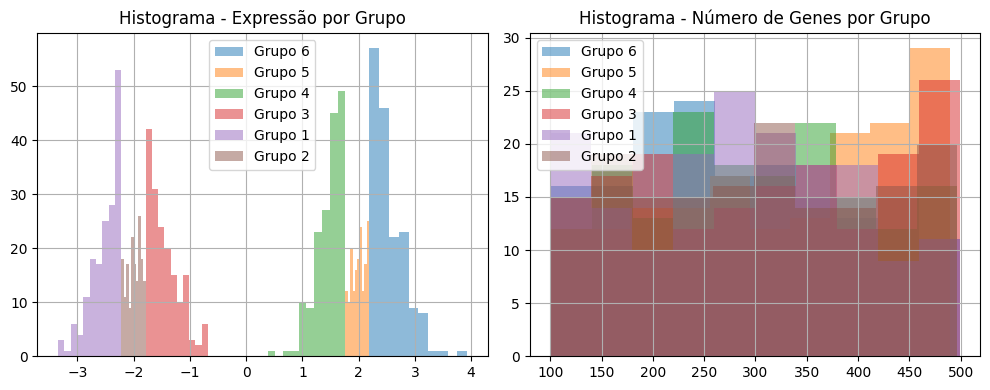

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for grupo in df["grupo"].unique():
    dados = df[df["grupo"] == grupo]["expressao"]
    dados.hist(alpha=0.5, label=grupo)
plt.title("Histograma - Expressão por Grupo")
plt.legend()

plt.subplot(1, 2, 2)
for grupo in df["grupo"].unique():
    dados = df[df["grupo"] == grupo]["num_genes"]
    dados.hist(alpha=0.5, label=grupo)
plt.title("Histograma - Número de Genes por Grupo")
plt.legend()

plt.tight_layout()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

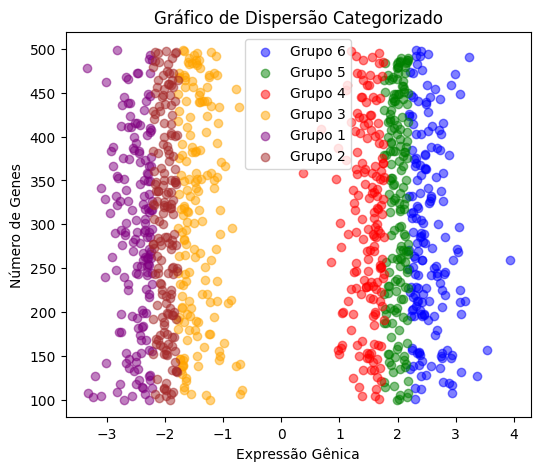

In [12]:
plt.figure(figsize=(6, 5))
cores = ["blue", "green", "red", "orange", "purple", "brown"]

for i, grupo in enumerate(df["grupo"].unique()):
    dados = df[df["grupo"] == grupo]
    plt.scatter(dados["expressao"], dados["num_genes"], 
                alpha=0.5, label=grupo, color=cores[i])

plt.title("Gráfico de Dispersão Categorizado")
plt.xlabel("Expressão Gênica")
plt.ylabel("Número de Genes")
plt.legend()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Tipo |
| :--- | :---: |
| # de células positivas| Discreta |
| % de células positivas| Contínua |
| Faixa de pH| Ordinal |
| Valor de pH| Contínua |
| mol/L| Contínua |
| UFC| Discreta |
| D.O.| Contínua |
| Grupo Sanguíneo| Nominal |
| Sorologia| Nominal |